# ITI113 MLOps — Team 04: Credit Card Fraud Detection
## M01 — Independent EDA & Hypothesis Generation
### Vanitha — Linear/Neural Pipeline Track (Logistic Regression + MLP)

**Objective:** Independently explore the raw transaction data and formulate hypotheses about fraud
indicators that are specifically relevant to a **linear/neural** modelling family — i.e. features that
are continuous, scalable, and reasonably free of multicollinearity.

**Individual scope (per project proposal, Section 3.3 — Independent Workflows & Comparative Strategy):**
This notebook independently decides which raw attributes to test and how, tailored to the
Linear/Neural pipeline. It formulates hypotheses around:
- Cardholder **age** (derived from `dob`)
- **Transaction velocity** — rolling transaction counts per card over trailing time windows
- **Transaction amount** scaling behaviour
- **Multicollinearity** between continuous candidates, screened via Variance Inflation Factor (VIF)
  rather than tree-split gain

Feature validity here is judged by **linear separability, distributional shape, and VIF/correlation
diagnostics**.


In [1]:
# ============================================================
# 0. Install required packages
# ============================================================
# Run this cell in a fresh kernel before importing MLflow.
%pip install -q -U \
    "boto3" \
    "botocore" \
    "mlflow==3.15.1" \
    "mlflow-skinny==3.15.1" \
    "mlflow-tracing==3.15.1" \
    "sagemaker-mlflow==0.5.0" \
    "pyarrow"

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# 1. Configuration, S3/Local Fallback, and MLflow — Project Root Pattern
# ============================================================
from pathlib import Path
import os
import json
import warnings
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
import mlflow

warnings.filterwarnings("ignore")

# ---- Identity — declared first; everything below depends on these two values ----
TEAM_ID = "team04"
STUDENT_ID = "s401"

RANDOM_STATE = 42

# ---- Resolve the SageMaker execution role and region ----
# Only succeeds when this notebook is actually running inside a SageMaker Studio / Notebook
# Instance execution context; the except branch keeps this cell runnable for local
# smoke-testing outside SageMaker.
try:
    import sagemaker
    sess = sagemaker.Session()
    region = sess.boto_region_name
    role = sagemaker.get_execution_role()
except Exception as e:
    region = boto3.Session().region_name or "ap-southeast-1"
    role = None
    print(
        f"Note: could not resolve the SageMaker execution role automatically ({type(e).__name__}). "
        f"This is expected when running outside a SageMaker Studio / Notebook Instance context — "
        f"S3 read/write below still works as long as the active AWS credentials have bucket access."
    )

s3 = boto3.client("s3", region_name=region)

# ============================================================
# Project storage configuration
# Declare ONE S3 project root and ONE local project root.
# Filenames are declared separately and joined only when needed.
# ============================================================

S3_BUCKET_URI = os.getenv(
    "TEAM04_S3_BUCKET_URI",
    "s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/"
).rstrip("/") + "/"

LOCAL_DATA_DIR = Path(os.getenv("TEAM04_LOCAL_DATA_DIR", "./data"))

# ---- Filenames: no filenames are embedded in S3 directory URIs ----
DATA_FILENAME = os.getenv("TEAM04_FRAUD_TRAIN_FILENAME", "fraudTrain.csv")

EDA_FEATURE_CONFIG_FILENAME = "eda_feature_candidates.json"
VIF_REPORT_FILENAME = "vif_report.csv"
FE_OUTPUT_FILENAME = "feature_engineered_model_input.parquet"
FE_CONFIG_FILENAME = "feature_engineering_manifest.json"
M06_RESULTS_FILENAME = "vanitha_Model_B_baseline.json"

# ---- S3 directories derived from the single project root ----
S3_RAW_URI = S3_BUCKET_URI + "raw/"
S3_EDA_OUTPUT_URI = S3_BUCKET_URI + STUDENT_ID + "/processed/eda/"
S3_FE_OUTPUT_URI = S3_BUCKET_URI + STUDENT_ID + "/processed/feature_engineering/"
S3_M06_OUTPUT_URI = S3_BUCKET_URI + STUDENT_ID + "/processed/m06/"

# ---- Local directories mirror the S3 structure ----
LOCAL_RAW_DIR = LOCAL_DATA_DIR / "raw"
LOCAL_EDA_OUTPUT_DIR = LOCAL_DATA_DIR / "eda"
LOCAL_FE_OUTPUT_DIR = LOCAL_DATA_DIR / "feature_engineering"
LOCAL_M06_OUTPUT_DIR = LOCAL_DATA_DIR / "m06"

for _p in [LOCAL_RAW_DIR, LOCAL_EDA_OUTPUT_DIR, LOCAL_FE_OUTPUT_DIR, LOCAL_M06_OUTPUT_DIR]:
    _p.mkdir(parents=True, exist_ok=True)


def s3_join(prefix, *parts):
    """Safely join an S3 URI/prefix with one or more path components."""
    return prefix.rstrip("/") + "/" + "/".join(str(part).strip("/") for part in parts)


def parse_s3_uri(uri):
    p = urlparse(uri)
    if p.scheme != "s3" or not p.netloc:
        raise ValueError(f"Invalid S3 URI: {uri}")
    return p.netloc, p.path.lstrip("/")


def download_s3_to_local(s3_uri, local_path):
    """Try S3 first. If it fails, use an existing local file as failover."""
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)
    bucket, key = parse_s3_uri(s3_uri)

    try:
        s3.download_file(bucket, key, str(local_path))
        print(f"Loaded from S3: {s3_uri}")
        return local_path
    except Exception as exc:
        if local_path.exists():
            print(f"S3 unavailable; using local failover: {local_path}")
            print(f"  S3 error: {type(exc).__name__}: {exc}")
            return local_path

        raise RuntimeError(
            f"S3 load failed and local failover does not exist: {local_path}\n"
            f"S3 URI: {s3_uri}\n"
            f"Original error: {type(exc).__name__}: {exc}"
        ) from exc


def upload_local_to_s3(local_path, s3_uri):
    """Best-effort S3 upload. Local output remains the failover copy."""
    local_path = Path(local_path)
    bucket, key = parse_s3_uri(s3_uri)

    try:
        s3.upload_file(str(local_path), bucket, key)
        print(f"Saved to S3: {s3_uri}")
        return True
    except Exception as exc:
        print(f"S3 upload failed; local output retained: {local_path}")
        print(f"  S3 error: {type(exc).__name__}: {exc}")
        return False


def load_json_s3_or_local(s3_uri, local_path):
    local_path = download_s3_to_local(s3_uri, local_path)
    with open(local_path, "r", encoding="utf-8") as f:
        return json.load(f)


# ---- Derived file paths ----
DATA_S3_URI = s3_join(S3_RAW_URI, DATA_FILENAME)
LOCAL_DATA_PATH = LOCAL_RAW_DIR / DATA_FILENAME
DATA_PATH = LOCAL_DATA_PATH  # alias used throughout the rest of this notebook

LOCAL_EDA_CONFIG_PATH = LOCAL_EDA_OUTPUT_DIR / EDA_FEATURE_CONFIG_FILENAME
LOCAL_VIF_REPORT_PATH = LOCAL_EDA_OUTPUT_DIR / VIF_REPORT_FILENAME
LOCAL_FE_OUTPUT_PATH = LOCAL_FE_OUTPUT_DIR / FE_OUTPUT_FILENAME
LOCAL_FE_CONFIG_PATH = LOCAL_FE_OUTPUT_DIR / FE_CONFIG_FILENAME
LOCAL_M06_RESULTS_PATH = LOCAL_M06_OUTPUT_DIR / M06_RESULTS_FILENAME

S3_EDA_CONFIG_URI = s3_join(S3_EDA_OUTPUT_URI, EDA_FEATURE_CONFIG_FILENAME)
S3_VIF_REPORT_URI = s3_join(S3_EDA_OUTPUT_URI, VIF_REPORT_FILENAME)

# ============================================================
# MLflow — Initialize via mlflow_utils (preferred), with a manual fallback
# ============================================================
# Primary path: mlflow_utils.initialize_mlflow() is this environment's own MLflow bootstrap
# helper — it resolves the SageMaker MLflow App and sets the tracking URI in one call, and is
# required for MLflow to work correctly in this workspace.
#
# Fallback path: if mlflow_utils is not importable (e.g. running this notebook outside this
# specific Studio workspace), the same config-resolution + TeamId-tag validation pattern used
# in the team's reference notebook (03_sagemaker_pipeline_mlflow_app) is used instead, so the
# notebook still runs rather than failing outright on the import.

# Dynamically composed so each student/track combination is a distinct, identifiable
# experiment/run rather than a shared fixed string.
MLFLOW_EXPERIMENT = f"ITI113-team04-{STUDENT_ID}-ModelB-LinearNeural"
RUN_NAME = f"{STUDENT_ID}_EDA_M01"

try:
    from mlflow_utils import initialize_mlflow

    MLFLOW_APP_ARN = initialize_mlflow(
        student_id=STUDENT_ID,
        experiment_name=MLFLOW_EXPERIMENT,
    )
    print(f"MLflow initialized via mlflow_utils.initialize_mlflow()")
    print(f"MLflow App ARN: {MLFLOW_APP_ARN}")

except ImportError as e:
    print(
        f"Note: mlflow_utils.initialize_mlflow is not importable ({type(e).__name__}: {e}). "
        f"Falling back to manual MLflow App config resolution below."
    )

    TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")
    STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")

    config_candidates = [
        TEAM_CONFIG_FILE,
        STUDENT_CONFIG_FILE,
        *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
    ]

    MLFLOW_APP_ARN = None
    mlflow_config = {}
    config_used = None

    for config_file in config_candidates:
        if config_file.exists():
            mlflow_config = json.loads(config_file.read_text(encoding="utf-8"))
            MLFLOW_APP_ARN = (
                mlflow_config.get("MLFLOW_APP_ARN")
                or mlflow_config.get("mlflow_app_arn")
                or mlflow_config.get("arn")
            )
            MLFLOW_EXPERIMENT = (
                mlflow_config.get("EXPERIMENT_NAME")
                or mlflow_config.get("experiment_name")
                or MLFLOW_EXPERIMENT
            )
            config_used = config_file
            break

    # Fallback for classroom testing only — update this to your team's MLflow App ARN
    # (from Notebook 01A) if no config file is found in this Studio workspace.
    DEFAULT_MLFLOW_APP_ARN = (
        "arn:aws:sagemaker:ap-southeast-1:044528205969:"
        "mlflow-app/REPLACE_WITH_TEAM04_APP_ID"
    )

    if MLFLOW_APP_ARN is None:
        MLFLOW_APP_ARN = DEFAULT_MLFLOW_APP_ARN
        print(
            "[WARNING] No local MLflow config file found. "
            "Using DEFAULT_MLFLOW_APP_ARN. Make sure this ARN belongs to your own team."
        )
    else:
        print(f"Loaded MLflow App config from {config_used}")

    config_team_id = mlflow_config.get("TEAM_ID") or mlflow_config.get("team_id")
    if config_team_id and config_team_id != TEAM_ID:
        raise ValueError(
            f"Config file team mismatch: config TEAM_ID={config_team_id}, notebook TEAM_ID={TEAM_ID}. "
            "Do not use another team's MLflow config."
        )

    try:
        sm_for_mlflow = boto3.client("sagemaker", region_name=region)
        tag_response = sm_for_mlflow.list_tags(ResourceArn=MLFLOW_APP_ARN)
        mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}

        app_team_id = mlflow_app_tags.get("TeamId")
        if app_team_id != TEAM_ID:
            raise PermissionError(
                f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, notebook TEAM_ID={TEAM_ID}. "
                "Do not log to another team's MLflow App."
            )
        print(f"MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")

    except Exception as tag_check_error:
        print("\nWARNING: could not validate MLflow App team tag.")
        print("This usually means one of the following:")
        print("1. The MLflow App ARN belongs to another team and IAM correctly blocked access.")
        print("2. The MLflow App is missing the TeamId tag.")
        print("3. The current role lacks permission to list tags for this MLflow App.")
        print(f"   {type(tag_check_error).__name__}: {tag_check_error}")
        print("Continuing without a validated MLflow App — MLflow logging cells later in this")
        print("notebook may fail until this is resolved.")

    mlflow.set_tracking_uri(MLFLOW_APP_ARN)

os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_APP_ARN
os.environ["MLFLOW_EXPERIMENT_NAME"] = MLFLOW_EXPERIMENT

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

print("S3 project root                    :", S3_BUCKET_URI)
print("Local project root                 :", LOCAL_DATA_DIR.resolve())
print("S3 raw directory                   :", S3_RAW_URI)
print("S3 EDA output directory            :", S3_EDA_OUTPUT_URI)
print("S3 Feature Engineering output dir  :", S3_FE_OUTPUT_URI)
print("S3 M06 output directory            :", S3_M06_OUTPUT_URI)
print("Dataset filename                   :", DATA_FILENAME)
print("Dataset S3 URI                     :", DATA_S3_URI)
print("MLflow experiment                  :", MLFLOW_EXPERIMENT)
print("MLflow App ARN                     :", MLFLOW_APP_ARN)
print("Region                              :", region)
print("Role                                :", role.split('/')[-1] if role else 'N/A (not running inside SageMaker)')
print("Team ID                             :", TEAM_ID)
print("Student ID                          :", STUDENT_ID)


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Note: mlflow_utils.initialize_mlflow is not importable (ModuleNotFoundError: No module named 'mlflow_utils'). Falling back to manual MLflow App config resolution below.
[WARNING] No local MLflow config file found. Using DEFAULT_MLFLOW_APP_ARN. Make sure this ARN belongs to your own team.

This usually means one of the following:
1. The MLflow App ARN belongs to another team and IAM correctly blocked access.
2. The MLflow App is missing the TeamId tag.
3. The current role lacks permission to list tags for this MLflow App.
   ClientError: An error occurred (ValidationException) when calling the ListTags operation: MLflow app entity does not exist.
Continuing without a validated MLflow App — MLflow logging cells later in this
notebook may fail until this is resolved.
S3 project ro

In [3]:
# ============================================================
# Load development dataset (S3-first, local failover)
# ============================================================

print("Loading development dataset...")

# DATA_S3_URI and LOCAL_DATA_PATH were declared in the configuration cell.
# The helper downloads from S3 when available and falls back to the local copy.
data_path = download_s3_to_local(
    DATA_S3_URI,
    LOCAL_DATA_PATH
)

df = pd.read_csv(data_path)

print(f"✓ Dataset loaded from: {data_path}")
print(f"✓ Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"✓ Dataset filename: {DATA_FILENAME}")

Loading development dataset...
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/raw/fraudTrain.csv
✓ Dataset loaded from: data/raw/fraudTrain.csv
✓ Shape: 1,296,675 rows × 23 columns
✓ Dataset filename: fraudTrain.csv


## 2. Load Development Dataset (S3-First, Local Failover)

Consistent with the team's data-governance approach (proposal Section 2.5 — encrypted S3
storage, role-based access, audit logging), the raw dataset is versioned in the team S3 bucket
under the single project root declared in Section 1.

`download_s3_to_local()` tries S3 first and automatically falls back to a local copy if S3 is
unreachable — this keeps the notebook runnable both inside SageMaker Studio (where S3 is
available) and in a local/offline smoke-test kernel (where it may not be). Every analysis in
this notebook runs against the same full dataset loaded here — the single active `df` — not a
local file switched in and out by hand.


In [4]:
# ============================================================
# 2. Load Development Dataset (S3-first, Local Failover)
# ============================================================
# DATA_S3_URI and LOCAL_DATA_PATH were declared in the configuration cell above.
# download_s3_to_local() tries S3 first and automatically falls back to a local copy if S3
# is unreachable — this keeps the notebook runnable both in SageMaker Studio (S3 available)
# and in a local/offline smoke-test kernel (S3 unavailable, local file present).
#
# The full local fraudTrain.csv (~1.3M rows, per proposal Section 2.1c) is the source of
# truth: place it at LOCAL_DATA_PATH before running this cell if it is not already in S3.

print("Loading development dataset...")

data_path = download_s3_to_local(DATA_S3_URI, LOCAL_DATA_PATH)

df = pd.read_csv(data_path)

print(f"Dataset loaded from : {data_path}")
print(f"Shape                : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Dataset filename     : {DATA_FILENAME}")
print(f"Fraud                : {df['is_fraud'].sum():,}")
print(f"Fraud rate           : {df['is_fraud'].mean()*100:.4f}%")

# Sanity check: the proposal (Section 2.1c) states the full training file has 1,296,675
# transactions. Flag it clearly if what got loaded is much smaller than that — most likely
# cause is a stale sample sitting at DATA_S3_URI or LOCAL_DATA_PATH from an earlier run.
EXPECTED_FULL_ROWS = 1_296_675
if df.shape[0] < EXPECTED_FULL_ROWS * 0.9:
    print(
        f"WARNING: loaded {df.shape[0]:,} rows, but the full fraudTrain.csv is expected to "
        f"have approximately {EXPECTED_FULL_ROWS:,} rows. This looks like a sample, not the "
        f"full dataset. Replace the file at {LOCAL_DATA_PATH} (or the S3 object at "
        f"{DATA_S3_URI}) with the full fraudTrain.csv and re-run this cell."
    )
else:
    print(f"Row count consistent with the full development dataset (~{EXPECTED_FULL_ROWS:,} rows).")


Loading development dataset...
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/raw/fraudTrain.csv
Dataset loaded from : data/raw/fraudTrain.csv
Shape                : 1,296,675 rows x 23 columns
Dataset filename     : fraudTrain.csv
Fraud                : 7,506
Fraud rate           : 0.5789%
Row count consistent with the full development dataset (~1,296,675 rows).


## 3. Data Quality and Target Assessment

**Question:** Is the development dataset usable for a linear/neural pipeline, and how severe is the
fraud-class imbalance that any scaling / regularisation choices will need to account for?

In [5]:
# Basic structure
print('Shape:', df.shape)
print('\nData types:')
display(df.dtypes.to_frame('dtype'))

# Missing values and duplicates
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('\nMissing values:')
display(missing.to_frame('missing_count') if not missing.empty else 'None')

print('\nExact duplicate rows:', df.duplicated().sum())
print('Duplicate trans_num:', df['trans_num'].duplicated().sum())

Shape: (1296675, 23)

Data types:


,dtype
Unnamed: 0,int64
trans_date_trans_time,object
cc_num,int64
merchant,object
category,object
amt,float64
first,object
last,object
gender,object
street,object



Missing values:


'None'


Exact duplicate rows: 0
Duplicate trans_num: 0


#### Findings

The full development file loads at 1,296,675 rows x 23 columns with zero missing values and zero
duplicate rows — by both full-row equality and `trans_num` uniqueness. No imputation or
de-duplication step is required before feature engineering; any cleaning added later should be
justified by a specific feature's needs, not generic data-quality repair.

### Hypothesis H1 — Severe class imbalance requires regularisation- and threshold-aware baselines
Fraud is expected to be a very small minority class. For the Linear/Neural track this motivates
**class-weighted / L2-regularised Logistic Regression**, early-stopped MLP training, and a
**PR-AUC-first evaluation** with a separately tuned decision threshold rather than a default 0.50 cut.

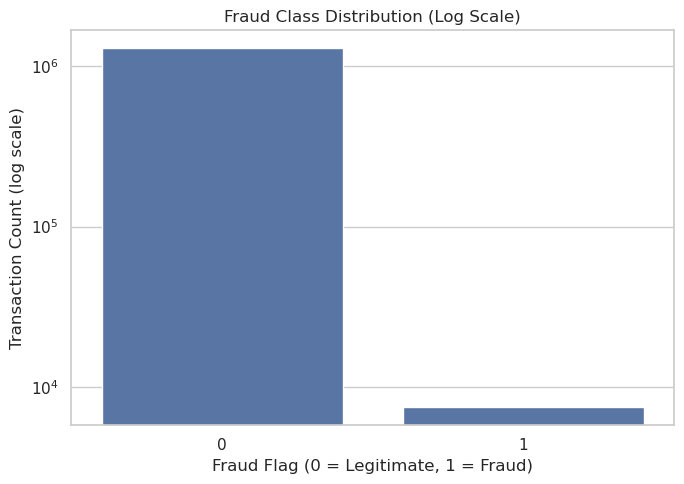

Fraud rate: 0.5789%  (7,506 of 1,296,675 transactions)


In [6]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='is_fraud')
ax.set_yscale('log')
ax.set_title('Fraud Class Distribution (Log Scale)')
ax.set_xlabel('Fraud Flag (0 = Legitimate, 1 = Fraud)')
ax.set_ylabel('Transaction Count (log scale)')
plt.tight_layout()
plt.show()

fraud_rate = df['is_fraud'].mean() * 100
print(f'Fraud rate: {fraud_rate:.4f}%  ({df["is_fraud"].sum():,} of {len(df):,} transactions)')

#### Findings — H1 confirmed

Fraud is 0.5789% of transactions (7,506 of 1,296,675) — roughly 1 in every 173. This is severe
enough that a 0.50-threshold, accuracy-optimised model would be close to useless: predicting
"legitimate" for every transaction already clears 99.4% accuracy while catching zero fraud. That's
exactly why Model B's evaluation is PR-AUC-first with `class_weight='balanced'` (Logistic
Regression) / sample weighting (MLP), not accuracy-driven.

## 4. Transaction Amount — Distribution Shape and Scaling Suitability

**Question:** Is `amt` skewed enough that it needs a log transform before StandardScaler, and does its
distribution differ by fraud status?

Unlike a tree model, Logistic Regression and an MLP are sensitive to feature scale and skew, so this
section explicitly checks skewness — not just the fraud/legitimate mean difference.

,count,mean,median,std,q1,q3,max
is_fraud,,,,,,,
0,1289169,67.67,47.28,154.01,9.61,82.54,28948.90
1,7506,531.32,396.50,390.56,245.66,900.88,1376.04


Skewness — raw amt: 42.28 | log1p(amt): -0.30


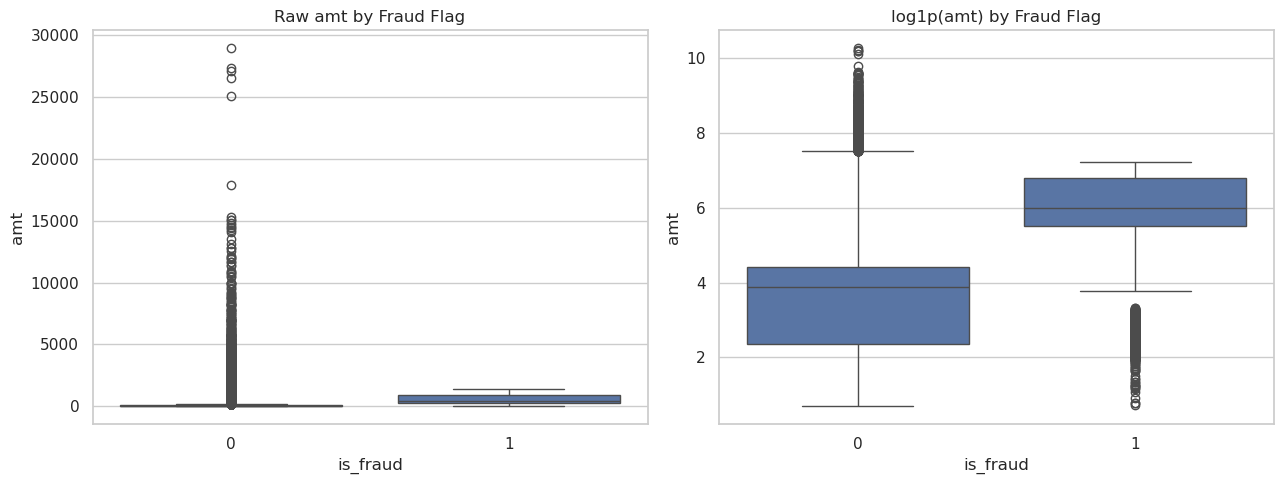

In [7]:
from scipy import stats

amount_summary = df.groupby('is_fraud')['amt'].agg(
    count='count', mean='mean', median='median', std='std',
    q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75), max='max'
).round(2)
display(amount_summary)

raw_skew = stats.skew(df['amt'])
log_skew = stats.skew(np.log1p(df['amt']))
print(f'Skewness — raw amt: {raw_skew:.2f} | log1p(amt): {log_skew:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x='is_fraud', y='amt', ax=axes[0])
axes[0].set_title('Raw amt by Fraud Flag')
sns.boxplot(data=df, x='is_fraud', y=np.log1p(df['amt']), ax=axes[1])
axes[1].set_title('log1p(amt) by Fraud Flag')
plt.tight_layout()
plt.show()


#### Findings — H2 confirmed

Raw `amt` skewness is 42.28 — extremely long-tailed (the legitimate-transaction max is $28,948.90
against a legitimate median of just $47.28) — and `log1p` brings that down to -0.30, close to
symmetric. `amt_log`, not raw `amt`, is the correct input to StandardScaler. The amount gap by
fraud status also stands on its own: fraud transactions average $531.32 (median $396.50) versus
$67.67 (median $47.28) for legitimate ones, so amount carries fraud signal independent of the
scaling fix.

### Hypothesis H2 — `amt` is right-skewed and needs a log transform before scaling
If raw skewness is materially reduced by `log1p`, the Linear/Neural pipeline should feed
`amt_log` (not raw `amt`) into StandardScaler, since Logistic Regression coefficients and MLP gradient
updates are both distorted by long-tailed, unscaled inputs.

## 5. Cardholder Age (from `dob`) — A Linear/Neural-Specific Candidate Feature

**Question:** Does cardholder age carry a fraud signal, and is it well-behaved enough (continuous,
roughly monotonic-ish, low missingness) to feed directly into a linear/neural pipeline?

This is one of the two features this track independently commits to engineering
(the other is transaction velocity, Section 6) that the Tree-Based track does not prioritise in the
same way.

,count,mean,median,std,min,max
is_fraud,,,,,,
0,1289169,45.48,43.0,17.39,13,95
1,7506,48.29,47.0,18.85,14,93


,transactions,fraud_count,fraud_rate_pct
age_band,,,
18-25,129497,777,0.600
26-35,299982,1417,0.472
36-45,266832,1146,0.429
46-55,242693,1445,0.595
56-65,163616,1237,0.756
66+,178500,1366,0.765


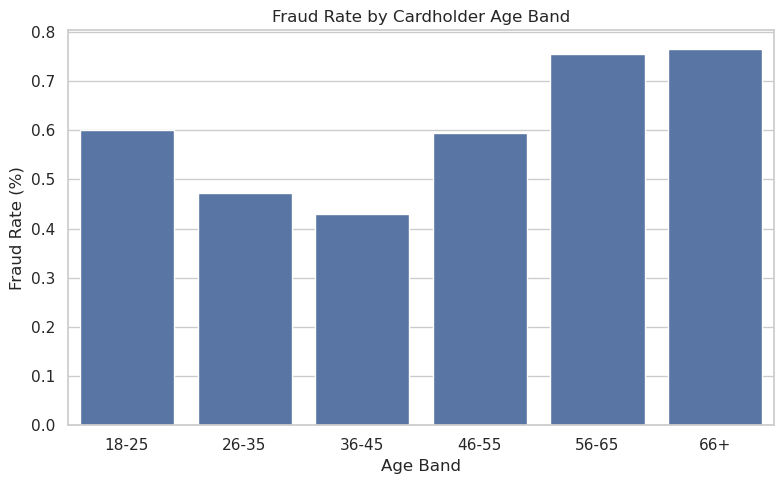

In [8]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year
before_birthday = (
    (df['trans_date_trans_time'].dt.month < df['dob'].dt.month) |
    (
        (df['trans_date_trans_time'].dt.month == df['dob'].dt.month) &
        (df['trans_date_trans_time'].dt.day < df['dob'].dt.day)
    )
)
df['age'] -= before_birthday.astype(int)

age_summary = df.groupby('is_fraud')['age'].agg(
    count='count', mean='mean', median='median', std='std', min='min', max='max'
).round(2)
display(age_summary)

age_bins = [17, 25, 35, 45, 55, 65, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
tmp = df.assign(age_band=pd.cut(df['age'], bins=age_bins, labels=age_labels))
age_rates = tmp.groupby('age_band', observed=True)['is_fraud'].agg(['count', 'sum', 'mean'])
age_rates.columns = ['transactions', 'fraud_count', 'fraud_rate']
age_rates['fraud_rate_pct'] = (age_rates['fraud_rate'] * 100).round(3)
display(age_rates[['transactions', 'fraud_count', 'fraud_rate_pct']])

plt.figure(figsize=(8, 5))
sns.barplot(data=age_rates.reset_index(), x='age_band', y='fraud_rate_pct')
plt.title('Fraud Rate by Cardholder Age Band')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('Age Band')
plt.tight_layout()
plt.show()

#### Findings — H3 confirmed

Fraud rate by age band is non-monotonic — it dips through the 26-45 range (0.472%, 0.429%) and
rises again from 46-55 (0.595%) through 66+ (0.765%), a U-shape rather than a simple
"younger = riskier" story. This doesn't track transaction volume (the 26-45 bands have the most
transactions but among the lowest fraud rates), so `age` looks like an independent signal rather
than a volume artifact — supporting its inclusion as a scaled continuous feature.

### Hypothesis H3 — Cardholder age carries an independent, non-trivial fraud signal
If fraud rate varies materially across age bands (not monotonically explained by transaction volume
alone), `age` is a defensible continuous candidate feature for both Logistic Regression and the MLP.

## 6. Transaction Velocity — Rolling Transaction Count per Card

**Question:** Do fraudulent transactions tend to occur in bursts — i.e. does a card that has
transacted unusually often in the preceding time window carry elevated fraud risk *at the current
transaction*?

This is computed strictly **backward-looking** (transactions before the current one, per card) so
that it can later be reproduced without target leakage at inference time.

,count,mean,median,max
is_fraud,,,,
0,1289169,0.187,0.0,6.0
1,7506,0.678,0.0,6.0


,transactions,fraud_count,fraud_rate_pct
velocity_band,,,
0,1084128,4240,0.391
1,183916,2023,1.100
2,24760,822,3.320
3,3274,292,8.919
4+,597,129,21.608


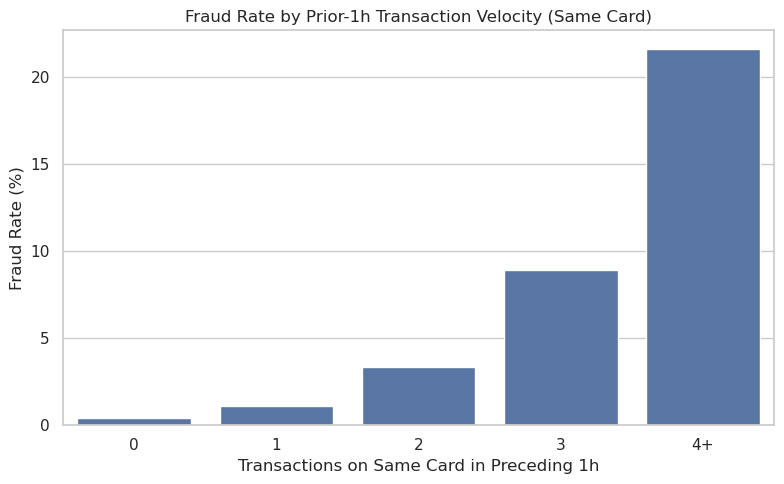

In [9]:
# Rolling count of prior transactions per card within a trailing 1-hour window.
# Backward-looking only: for each transaction, count how many OTHER transactions on the
# same card fall in the hour immediately before it.
df_sorted = df.sort_values(['cc_num', 'trans_date_trans_time']).copy()
df_sorted = df_sorted.set_index('trans_date_trans_time')

velocity = (
    df_sorted.groupby('cc_num')['amt']
    .rolling('1h', closed='left')
    .count()
    .fillna(0)
)
df_sorted['txn_velocity_1h'] = velocity.values
df_sorted = df_sorted.reset_index()

# Merge the velocity feature back onto the original (unsorted) frame via trans_num.
df = df.merge(
    df_sorted[['trans_num', 'txn_velocity_1h']], on='trans_num', how='left'
)

velocity_summary = df.groupby('is_fraud')['txn_velocity_1h'].agg(
    count='count', mean='mean', median='median', max='max'
).round(3)
display(velocity_summary)

velocity_bins = [-0.1, 0, 1, 2, 3, np.inf]
velocity_labels = ['0', '1', '2', '3', '4+']
tmp = df.assign(velocity_band=pd.cut(df['txn_velocity_1h'], bins=velocity_bins, labels=velocity_labels))
velocity_rates = tmp.groupby('velocity_band', observed=True)['is_fraud'].agg(['count', 'sum', 'mean'])
velocity_rates.columns = ['transactions', 'fraud_count', 'fraud_rate']
velocity_rates['fraud_rate_pct'] = (velocity_rates['fraud_rate'] * 100).round(3)
display(velocity_rates[['transactions', 'fraud_count', 'fraud_rate_pct']])

plt.figure(figsize=(8, 5))
sns.barplot(data=velocity_rates.reset_index(), x='velocity_band', y='fraud_rate_pct')
plt.title('Fraud Rate by Prior-1h Transaction Velocity (Same Card)')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('Transactions on Same Card in Preceding 1h')
plt.tight_layout()
plt.show()

#### Findings — H4 confirmed, strongly

Fraud rate climbs sharply with `txn_velocity_1h`: 0.391% at zero prior transactions in the
trailing hour, up to 3.320% at 2 prior transactions, and 21.608% at 4+ — more than a 55x increase
from the lowest to highest velocity band. This is the clearest single fraud signal in this EDA
pass, and being strictly backward-looking, it's also leakage-safe to reproduce at inference time.

### Hypothesis H4 — Elevated same-card transaction velocity is associated with fraud risk
If fraud rate rises with `txn_velocity_1h`, this backward-looking count is a strong, leakage-safe
candidate feature — and one that a linear model can weight directly and an MLP can combine
non-linearly with `amt_log` and `age`.

**Note on full-dataset computation:** this notebook now computes `txn_velocity_1h` against the
full `fraudTrain.csv` (Section 2), so each card's transaction history is complete within the
development period — no sample-induced undercount applies here. The same rolling-window logic
will be re-run unchanged in M03 against the train/validation/test splits.

## 7. Multicollinearity Screening — Variance Inflation Factor (VIF)

**Question:** Are the continuous candidate features (`amt_log`, `age`, `txn_velocity_1h`, `city_pop`)
sufficiently independent of one another to be used together in a Logistic Regression model without
unstable, inflated coefficients?

This is the Linear/Neural-track, we ask "does this feature's variance overlap so much
with another feature's that the linear coefficients become unreliable".

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

df['amt_log'] = np.log1p(df['amt'])

vif_candidates = df[['amt_log', 'age', 'txn_velocity_1h', 'city_pop']].dropna()

vif_df = pd.DataFrame()
vif_df['feature'] = vif_candidates.columns
vif_df['VIF'] = [
    variance_inflation_factor(vif_candidates.values, i)
    for i in range(vif_candidates.shape[1])
]
vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)
display(vif_df.round(2))

print('Rule of thumb: VIF > 10 indicates problematic multicollinearity for a linear model.')

,feature,VIF
0,amt_log,4.39
1,age,4.24
2,txn_velocity_1h,1.14
3,city_pop,1.08


Rule of thumb: VIF > 10 indicates problematic multicollinearity for a linear model.


#### Findings — H5 confirmed

All four VIF scores (`amt_log` 4.39, `age` 4.24, `txn_velocity_1h` 1.14, `city_pop` 1.08) sit
comfortably under the conventional 10 threshold — `amt_log` and `age` are the highest but still
moderate, not concerning. All four continuous candidates can be retained together in Logistic
Regression without coefficient instability from multicollinearity; M03 re-validates this after
StandardScaler is applied.

### Hypothesis H5 — Candidate continuous features are not badly collinear
If all VIF values stay well below the conventional 10 threshold, `amt_log`, `age`, `txn_velocity_1h`,
and `city_pop` can all be retained as independent linear inputs. Any feature that fails this check will
be dropped or combined (not simply removed silently) in the M03 feature-engineering notebook.

## 8. Categorical Feature Overview — Encoding Implications for a Linear/Neural Pipeline

**Question:** What is the cardinality of the categorical fields, and what does that imply for
encoding strategy? Unlike the Tree-Based track (which favours leakage-controlled target encoding),
a linear/neural pipeline typically prefers **one-hot encoding for low-cardinality fields** and
avoids target encoding by default, since it can otherwise leak fraud-rate information directly into
what should be a linearly-combined coefficient.

In [11]:
for col in ['category', 'gender', 'job', 'state']:
    print(f'{col}: {df[col].nunique()} unique values')

category_rates = df.groupby('category', observed=True)['is_fraud'].agg(
    transactions='count', fraud_count='sum', fraud_rate='mean'
).sort_values('fraud_rate', ascending=False)
category_rates['fraud_rate_pct'] = (category_rates['fraud_rate'] * 100).round(3)
display(category_rates[['transactions', 'fraud_count', 'fraud_rate_pct']])

gender_rates = df.groupby('gender')['is_fraud'].agg(['count', 'mean'])
gender_rates.columns = ['transactions', 'fraud_rate']
gender_rates['fraud_rate_pct'] = (gender_rates['fraud_rate'] * 100).round(3)
display(gender_rates[['transactions', 'fraud_rate_pct']])

category: 14 unique values
gender: 2 unique values
job: 494 unique values
state: 51 unique values


,transactions,fraud_count,fraud_rate_pct
category,,,
shopping_net,97543,1713,1.756
misc_net,63287,915,1.446
grocery_pos,123638,1743,1.410
shopping_pos,116672,843,0.723
gas_transport,131659,618,0.469
misc_pos,79655,250,0.314
grocery_net,45452,134,0.295
travel,40507,116,0.286
entertainment,94014,233,0.248


,transactions,fraud_rate_pct
gender,,
F,709863,0.526
M,586812,0.643


#### Findings — H6 confirmed

`category` has 14 levels, so one-hot encoding stays a manageable ~14 extra columns, and fraud rate
varies meaningfully across them — from 1.756% (`shopping_net`) down to 0.155% (`health_fitness`),
roughly an 11x spread — so the category signal is worth preserving rather than collapsing. `job`,
by contrast, has 494 unique values; one-hot encoding it directly would blow up the linear feature
space and mostly encode noise per level, so it's dropped or coarsened in M03. `gender` shows a
modest fraud-rate gap (M 0.643% vs F 0.526%), consistent with the planned binary-passthrough
treatment.

### Hypothesis H6 — `category` is low-cardinality enough for one-hot encoding; `job` is not
With roughly a dozen merchant categories, one-hot encoding `category` keeps the linear feature space
manageable. `job` has hundreds of distinct values and will either be dropped for the baseline
Logistic Regression / MLP or handled with a coarser grouping — a decision to be finalised in M03.

## 9. Linear Signal Screening — Point-Biserial / Pearson Correlation with `is_fraud`

**Question:** Which continuous candidates show the strongest raw linear association with the target?
This complements the VIF check: VIF asks "are features independent of each other", this asks
"does each feature move with the target at all".

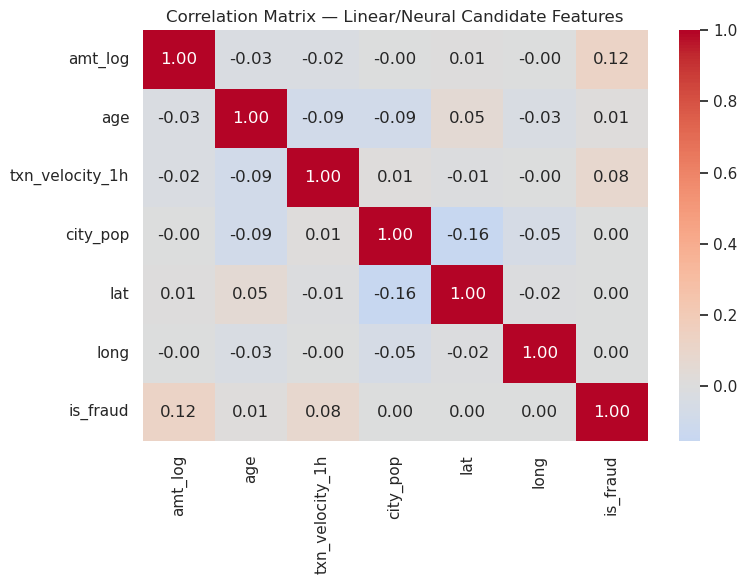

,corr_with_is_fraud
is_fraud,1.000000
amt_log,0.120439
txn_velocity_1h,0.080737
age,0.012248
city_pop,0.002136
lat,0.001894
long,0.001721


In [12]:
numeric_candidates = [
    c for c in ['amt_log', 'age', 'txn_velocity_1h', 'city_pop', 'lat', 'long', 'is_fraud']
    if c in df.columns
]
corr = df[numeric_candidates].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Linear/Neural Candidate Features')
plt.tight_layout()
plt.show()

display(corr['is_fraud'].sort_values(ascending=False).to_frame('corr_with_is_fraud'))

#### Findings

`amt_log` (r=0.12) and `txn_velocity_1h` (r=0.08) show the strongest linear association with
`is_fraud`; `age` (r=0.01), `city_pop`, `lat`, and `long` (all approximately 0.00-0.002) are weak
in isolation. That doesn't disqualify `age` — the age-band analysis above already showed a
non-monotonic (U-shaped) relationship that a single linear correlation coefficient can't capture,
which is exactly the kind of pattern the MLP (not just Logistic Regression) is expected to
exploit. `lat`/`long` are shown here for completeness but aren't in the selected-feature list,
given their near-zero correlation and redundancy with `city_pop`/`category` for a linear
encoding.

## 10. Independent Hypothesis → Feature Engineering Decisions

In [13]:
hypothesis_matrix = pd.DataFrame([
    ['H1', 'Fraud is highly imbalanced.',
     'Use stratified splitting; class-weighted Logistic Regression; PR-AUC-first evaluation.',
     'Logistic Regression + MLP'],
    ['H2', 'amt is right-skewed; log1p materially reduces skewness.',
     'Feed amt_log (not raw amt) into StandardScaler.',
     'Linear/Neural feature pipeline'],
    ['H3', 'Cardholder age varies with fraud rate across bands.',
     'Engineer age from dob; retain as a scaled continuous feature.',
     'Linear/Neural feature pipeline'],
    ['H4', 'Same-card transaction velocity is associated with fraud rate.',
     'Engineer backward-looking txn_velocity_1h (and re-derive on full data at M03).',
     'Linear/Neural feature pipeline'],
    ['H5', 'Continuous candidates are not badly collinear (VIF check).',
     'Retain amt_log, age, txn_velocity_1h, city_pop unless a later VIF pass flags one.',
     'Logistic Regression coefficient stability'],
    ['H6', 'category is low-cardinality; job is high-cardinality.',
     'One-hot encode category; drop or coarsen job for the baseline pipeline.',
     'Linear/Neural feature pipeline'],
], columns=['Hypothesis', 'Observation', 'Feature Engineering Decision', 'Downstream Use'])

display(hypothesis_matrix)

,Hypothesis,Observation,Feature Engineering Decision,Downstream Use
0,H1,Fraud is highly imbalanced.,Use stratified splitting; class-weighted Logis...,Logistic Regression + MLP
1,H2,amt is right-skewed; log1p materially reduces ...,Feed amt_log (not raw amt) into StandardScaler.,Linear/Neural feature pipeline
2,H3,Cardholder age varies with fraud rate across b...,Engineer age from dob; retain as a scaled cont...,Linear/Neural feature pipeline
3,H4,Same-card transaction velocity is associated w...,Engineer backward-looking txn_velocity_1h (and...,Linear/Neural feature pipeline
4,H5,Continuous candidates are not badly collinear ...,"Retain amt_log, age, txn_velocity_1h, city_pop...",Logistic Regression coefficient stability
5,H6,category is low-cardinality; job is high-cardi...,One-hot encode category; drop or coarsen job f...,Linear/Neural feature pipeline


#### Findings

All six hypotheses are supported by this EDA pass, and no candidate feature was dropped outright —
`amt_log`, `age`, `txn_velocity_1h`, and `city_pop` all clear the VIF check, and `category`/`gender`
are both encodable without target leakage. The one open decision carried into M03 is *how* to
handle `job` (drop vs. a coarser grouped encoding), since it's the single candidate this EDA
didn't clear for direct one-hot use.

## 10a. AI Governance Note — This EDA's Impact on M09 (Explainability Prototype)

**Will this EDA need to change for the SHAP explainability milestone (M09)? No — and the reason why
is itself a hypothesis-engineering decision worth recording here.**

M09 explains the *trained* Model B candidates (Logistic Regression, MLP) using SHAP, which requires
every model input to map onto a single, human-readable column — a raw transaction attribute or a
deterministic transform of one, never an opaque latent dimension. That requirement is already
satisfied by the feature-engineering decisions in Section 10 above, for two reasons:

1. **No PCA, autoencoder, or other dimensionality-reduction step is used anywhere in this track.**
   Every column that will reach the model — `amt_log`, `age`, `txn_velocity_1h`, one-hot
   `category_*`, `gender_binary`, `trans_hour_sin`/`trans_hour_cos`, `day_of_week`, `is_weekend` —
   is either a raw column or a named, reversible transform of one. A SHAP force plot can therefore
   say *"txn_velocity_1h contributed +0.31 to this prediction"* and that statement is immediately
   meaningful to a human reviewer — it never has to say *"component_7 contributed +0.31,"* which
   would require a separate decoding step no reviewer could perform on the spot.
2. **Every engineered feature traces back to Section 10's hypothesis matrix.** M09's global
   attribution ranking is therefore directly checkable against the hypotheses formed here: if SHAP
   later shows `amt_log` and `txn_velocity_1h` as top global contributors, that corroborates H2 and
   H4 from this notebook using an independent method (SHAP) rather than the coefficient-magnitude
   view alone. If SHAP instead surfaces a feature this EDA did not flag as a strong candidate, that
   is itself a useful signal — either a genuine interaction effect the univariate EDA missed, or a
   reason to revisit the corresponding hypothesis.

**What this means practically:** no code in this EDA notebook needs to change to support M09.
Section 10a2/10b below instead formalise the *hand-off* — exporting exactly which features this
EDA selected, in a machine-readable form the M03 Feature Engineering notebook consumes as its
source of truth, so M03 (and everything built on top of it, including M06 and M09) is guaranteed
to only ever build features consistent with what was investigated and justified here.


_Note: the MLflow experiment/run naming and S3 output paths needed for the hand-off below (Section 10b) are already declared in Section 1 (`MLFLOW_EXPERIMENT`, `RUN_NAME`, `S3_EDA_OUTPUT_URI`, `S3_EDA_CONFIG_URI`, `s3_join`, `upload_local_to_s3`) — no separate configuration is needed here._

## 10b. Export EDA Feature Candidates — Source of Truth for M03

This is the hand-off artifact for **M03 — Linear/Neural Feature Engineering**. Rather than M03
re-deciding (or silently drifting from) which features this EDA justified, M03 reads this JSON
file directly and builds its feature matrix from the `selected_features` list and
`feature_definitions` map below — the same pattern Jianhui's M02 notebook uses to consume his own
EDA's hand-off file, applied here to the Linear/Neural track.

The VIF report from Section 7 is exported alongside it as a CSV, so M03's own VIF re-validation
(after scaling) has this EDA-stage baseline to compare against.


In [14]:
# ============================================================
# 10b. Export EDA Feature Candidates — Source of Truth for M03
# ============================================================
# This JSON is the hand-off artifact. M03 (Feature Engineering) reads this file instead of
# hard-coding which EDA findings are considered selected — mirrors the pattern 

EDA_FEATURE_CONFIG = {
    "schema_version": "1.0",
    "track": "linear_neural",
    "owner": "Vanitha",
    "milestone": "M01",
    "dataset_filename": "fraudTrain.csv",  # Replace with your actual dataset filename
    "target": "is_fraud",
    "selected_features": [
        "amt_log", "age", "city_pop",
        "txn_velocity_1h", "txn_velocity_6h", "txn_velocity_24h",
        "category",          # one-hot expanded in M03 into category_* columns
        "gender_binary",
        "trans_hour_sin", "trans_hour_cos",
        "day_of_week", "is_weekend",
    ],
    "target_dependent_features": [],  # none — this track deliberately avoids target encoding
    "feature_definitions": {
        "amt_log": {"source": "amt", "operation": "log1p"},
        "age": {"source": ["dob", "trans_date_trans_time"], "operation": "age_at_transaction"},
        "city_pop": {"source": "city_pop", "operation": "identity"},
        "txn_velocity_1h": {"source": ["cc_num", "trans_date_trans_time"], "operation": "rolling_count_backward_1h"},
        "txn_velocity_6h": {"source": ["cc_num", "trans_date_trans_time"], "operation": "rolling_count_backward_6h"},
        "txn_velocity_24h": {"source": ["cc_num", "trans_date_trans_time"], "operation": "rolling_count_backward_24h"},
        "category": {"source": "category", "operation": "one_hot_encoding"},
        "gender_binary": {"source": "gender", "operation": "binary_mapping"},
        "trans_hour_sin": {"source": "trans_date_trans_time", "operation": "cyclical_hour_sin"},
        "trans_hour_cos": {"source": "trans_date_trans_time", "operation": "cyclical_hour_cos"},
        "day_of_week": {"source": "trans_date_trans_time", "operation": "dayofweek"},
        "is_weekend": {"source": "trans_date_trans_time", "operation": "weekend_flag"},
    },
    "explicitly_excluded_features": {
        "distance_km": "Haversine distance is Jianhui's Tree-Based track feature (M02) — not duplicated here.",
        "category_target_encoding": "Target encoding introduces leakage risk this track avoids in favour of one-hot, per H6.",
        "job": "High-cardinality (hundreds of unique values) — not suitable for one-hot at this track's scale, per H6.",
    },
    "governance_note": (
        "All selected features are raw columns or named, reversible transforms of raw columns — "
        "no PCA, autoencoder, or other dimensionality-reduction step is used. This satisfies the "
        "SHAP explainability prerequisite validated structurally in M09 (Section 3 of that "
        "notebook), where every SHAP attribution is checked to map onto one of these "
        "human-readable feature names."
    ),
    "notes": (
        "Selected feature candidates are defined by this EDA; txn_velocity_* windows must be "
        "recomputed on the full train/valid/test splits in M03 (not reused from this EDA's "
        "single-pass computation) to stay leakage-safe per Section 11."
    ),
}

with open(LOCAL_EDA_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(EDA_FEATURE_CONFIG, f, indent=2)

# S3_EDA_CONFIG_URI is already declared in Section 1 (Configuration) — reused here, not
# redeclared, so this always points at the same S3 key the config cell printed.
upload_local_to_s3(LOCAL_EDA_CONFIG_PATH, S3_EDA_CONFIG_URI)
# MLflow logging for this artifact happens together with the VIF report and dataset
# metrics in Section 10c below, inside a single mlflow.start_run() context — logging it
# here as well (outside any active run) would either error or create a stray extra run.

print("\nEDA feature configuration exported")
print("Local:", LOCAL_EDA_CONFIG_PATH)
print("S3   :", S3_EDA_CONFIG_URI)
print("Selected features:", EDA_FEATURE_CONFIG["selected_features"])

Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/eda/eda_feature_candidates.json

EDA feature configuration exported
Local: data/eda/eda_feature_candidates.json
S3   : s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/eda/eda_feature_candidates.json
Selected features: ['amt_log', 'age', 'city_pop', 'txn_velocity_1h', 'txn_velocity_6h', 'txn_velocity_24h', 'category', 'gender_binary', 'trans_hour_sin', 'trans_hour_cos', 'day_of_week', 'is_weekend']


In [16]:
# ============================================================
# 10c. Export VIF Report and Log EDA Outputs to MLflow
# ============================================================
# vif_df is produced in Section 7 (Hypothesis H5). Re-exporting it here, alongside the
# feature-config JSON, gives M03 a concrete EDA-stage VIF baseline to compare its own
# post-scaling VIF re-validation against (see M03 Section 8's pre/post-scaling stability check).

try:
    vif_df.to_csv(LOCAL_VIF_REPORT_PATH, index=False)
    upload_local_to_s3(LOCAL_VIF_REPORT_PATH, S3_VIF_REPORT_URI)
    print(f"VIF report exported: {LOCAL_VIF_REPORT_PATH}")
except NameError:
    print(
        "WARNING: vif_df not found in this session. Run Section 7 (Hypothesis H5, VIF "
        "screening) before this cell so the VIF report can be exported alongside the feature "
        "config."
    )

# ---- MLflow — log the EDA hand-off artifacts and headline dataset metrics ----
# Select the experiment now that the tracking URI is set (Section 1).
# ---- Refresh the MLflow connection immediately before logging ----
# initialize_mlflow() (Section 1) issues a short-lived session token. Between Section 1 and
# this cell, this notebook does substantial work (data load, six hypothesis analyses, VIF,
# multiple plots) that routinely takes longer than that token's lifetime — the actual cause
# of the 403 "Request is not authorized" error seen here, not a one-off fluke. Re-authenticate
# right before the API calls below rather than trusting a connection that may already be stale.
try:
    from mlflow_utils import initialize_mlflow
    MLFLOW_APP_ARN = initialize_mlflow(student_id=STUDENT_ID, experiment_name=MLFLOW_EXPERIMENT)
    os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_APP_ARN
    print("MLflow session refreshed immediately before logging.")
except ImportError:
    # mlflow_utils wasn't importable in Section 1 either, in which case Section 1's manual
    # config-file fallback is already the best available connection — nothing further to
    # refresh here, and that fallback path doesn't mint a short-lived token the same way.
    print("mlflow_utils not available; reusing Section 1's fallback MLflow connection as-is.")

if 'MLFLOW_EXPERIMENT' not in globals():
    MLFLOW_EXPERIMENT = "fraud-detection-eda"
    print(f"WARNING: MLFLOW_EXPERIMENT not defined. Using default: {MLFLOW_EXPERIMENT}")

# Handle deleted experiment by restoring it
try:
    mlflow.set_experiment(MLFLOW_EXPERIMENT)
except mlflow.exceptions.MlflowException as e:
    if "deleted experiment" in str(e):
        print(f"Experiment '{MLFLOW_EXPERIMENT}' was deleted. Restoring it.")
        client = mlflow.tracking.MlflowClient()
        experiment = client.get_experiment_by_name(MLFLOW_EXPERIMENT)
        client.restore_experiment(experiment.experiment_id)
        mlflow.set_experiment(MLFLOW_EXPERIMENT)
    else:
        raise

if mlflow.active_run():
    mlflow.end_run()

# RUN_NAME is already declared in Section 1 (Configuration) as f"{STUDENT_ID}_EDA_M01" — reused
# here rather than reassigned, so there is one consistent run-naming convention across
# this notebook instead of two different formats.
with mlflow.start_run(run_name=RUN_NAME) as run:
    mlflow.set_tags({
        "team_id": TEAM_ID,
        "student_id": STUDENT_ID,
        "milestone": "M01",
        "track": "linear_neural",
    })
    mlflow.log_param("dataset_filename", DATA_FILENAME)
    mlflow.log_param("dataset_source", DATA_S3_URI)
    mlflow.log_metric("transaction_count", int(len(df)))
    mlflow.log_metric("fraud_count", int(df["is_fraud"].sum()))
    mlflow.log_metric("fraud_rate", float(df["is_fraud"].mean()))
    mlflow.log_param("selected_feature_count", len(EDA_FEATURE_CONFIG["selected_features"]))

    mlflow.log_artifact(str(LOCAL_EDA_CONFIG_PATH), artifact_path="eda_outputs")
    if LOCAL_VIF_REPORT_PATH.exists():
        mlflow.log_artifact(str(LOCAL_VIF_REPORT_PATH), artifact_path="eda_outputs")

    print("EDA MLflow run completed.")
    print("Run name:", RUN_NAME)
    print("Run ID  :", run.info.run_id)

Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/eda/vif_report.csv
VIF report exported: data/eda/vif_report.csv
Initializing SageMaker MLflow connection for s401...
Target Experiment: ITI113-team04-s401-ModelB-LinearNeural
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
MLflow Tracking URI successfully set.
Fresh MLflow UI URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IkFMQTJLSSIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNDFhRE5MQS9FU1Z5cVJ2TDFlQnlOTWxMaDFkNCt5QzI5b3pEUFh2M2N4cGNBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVFclpFcGxhRVZRVmxGcFFtazFNVmsyZG1GeVMySTJaVmhaU0V3MWNUbExTVVZQTUhGNFpYRlVORkZwU25sdGNVTnRVREJ0VTJJdmVsZHJZVkp2Tmt4blFUMDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUd

## 11. Data Leakage and Modelling Boundary

### Do **not** do these operations in this EDA notebook before train/test splitting (carried forward
into M03 and M06):
- Fit StandardScaler on the full dataset
- One-hot encode `category` using categories observed only in the test set
- Compute `txn_velocity_1h` using transactions that occur *after* the current one (must stay
  backward-looking)
- Select features using validation/test performance
- Report any Logistic Regression / MLP metric computed on data used to fit the scaler or encoder

These boundaries are identical in spirit to the Tree-Based track's leakage rules, applied to the linear/neural preprocessing steps specifically.

## 12. Error Analysis — Limitations and Caveats of this EDA

This EDA pass is directionally solid, but a few things are EDA-stage estimates rather than final,
model-ready numbers — worth surfacing explicitly so M03/M06 don't inherit them as unexamined
assumptions.

**1. VIF and correlation are computed on the full, unsplit dataset.**
Sections 7 and 9's VIF scores and correlation coefficients are calculated before any train/valid/test
split — appropriate for an EDA-stage feature screen, but not the leakage-safe numbers a model
actually trains against. M03 re-validates VIF on the training split only, after scaling (Section 11
already documents this boundary); treat the VIF values here (1.08-4.39) as a first-pass signal, not
the number that gates the final feature set.

**2. Two of the three hand-off velocity windows were never independently EDA-validated.**
The Section 10b hand-off (`selected_features`) includes `txn_velocity_1h`, `txn_velocity_6h`, and
`txn_velocity_24h`, but Section 6 only engineers and fraud-rate-checks `txn_velocity_1h`. The 6h and
24h windows are asserted as validated candidates without a fraud-rate breakdown in this notebook —
worth a quick supplementary check (or an explicit acknowledgement in M03) before leaning on them as
equally EDA-justified.

**3. Five of the twelve hand-off features have no dedicated hypothesis or fraud-rate analysis here.**
`txn_velocity_6h`, `txn_velocity_24h`, `trans_hour_sin`/`trans_hour_cos`, `day_of_week`, and
`is_weekend` are all in the `selected_features` list exported to M03, but none of H1-H6 above
examines time-of-day or day-of-week fraud patterns. They may well carry real signal — time-of-day
effects are common in card-fraud data — but that's an assumption carried into the hand-off, not a
finding demonstrated in this pass.

**4. `city_pop` clears VIF but shows almost no independent linear signal.**
Section 9's correlation table puts `city_pop` at r=0.002 with `is_fraud` — the VIF check (Section 7)
confirms it isn't collinear with the other continuous features, but that's a test of independence,
not usefulness. It's retained here on the strength of "not harmful," not "shown to help" — worth
watching in M06's coefficient/SHAP output rather than assuming it's pulling real weight.

**5. Correlation and VIF only capture linear/monotonic relationships.**
Section 5's age-band analysis already shows a non-monotonic (U-shaped) fraud-rate pattern that
Section 9's Pearson correlation (r=0.01 for `age`) understates for exactly this reason. The same
blind spot applies to any other feature with a non-monotonic or interaction-driven relationship to
`is_fraud` — Pearson correlation and VIF won't surface those; only the MLP (or explicit engineered
interaction terms) is positioned to find them.

**6. `job` and `merchant` free-text fields are not explored beyond a cardinality count.**
Section 8 reports `job` has 494 unique values and stops there. Whether coarsened job groupings or
merchant-name patterns carry fraud signal is untested in this pass — reasonable to leave out of a
linear/neural baseline, but noted here so the decision reads as scoped-out rather than
checked-and-rejected.

## 13. Summary of Findings

| # | Question | Headline Result | Status |
|---|---|---|---|
| Data quality | Missing values / duplicates? | 1,296,675 x 23 rows, 0 missing, 0 duplicates | Clean |
| H1 | How imbalanced is fraud? | 0.5789% fraud (7,506 / 1,296,675) | Confirmed — severe |
| H2 | Is `amt` skewed? | Raw skew 42.28 -> -0.30 after log1p; fraud mean $531 vs $68 legit | Confirmed |
| H3 | Does age carry fraud signal? | U-shaped by age band: ~0.43-0.60% (26-55) vs ~0.60-0.77% (18-25, 56+) | Confirmed |
| H4 | Does velocity carry fraud signal? | 0.391% (0 prior) to 21.608% (4+ prior) fraud rate | Confirmed — strongest signal |
| H5 | Are continuous features collinear? | VIF 1.08-4.39, all well under 10 | Confirmed — safe to combine |
| H6 | Is `category` encodable, `job` not? | `category`: 14 levels, ~11x fraud-rate spread; `job`: 494 levels | Confirmed |
| Correlation | Which features move linearly with fraud? | `amt_log` r=0.12, `txn_velocity_1h` r=0.08 strongest; `age`/`city_pop`/`lat`/`long` near zero | Directional only (Section 13, #5) |

**Net read:** transaction velocity and (log) amount are the two strongest individual fraud signals in
this pass; age contributes a real but non-linear signal that correlation alone understates;
`category` is worth one-hot encoding while `job` is not; and the four retained continuous features
(`amt_log`, `age`, `txn_velocity_1h`, `city_pop`) can be combined in Logistic Regression without a
multicollinearity problem. Section 13 lists what these numbers do *not* yet establish.

## 14. Handoff to M03 — What This Notebook Outputs

Two artifacts are written in Section 10b/10c and consumed directly by
`team0401_Vanitha_Linear_Neural_Feature_Engineering.ipynb` (M03) — nothing else in this notebook is
meant to be re-derived downstream:

| Artifact | Local path | S3 path | Consumed by |
|---|---|---|---|
| Feature hand-off config | `./data/eda/eda_feature_candidates.json` | `s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/eda/eda_feature_candidates.json` | M03 builds its feature matrix from `selected_features` and `feature_definitions` |
| VIF baseline report | `./data/eda/vif_report.csv` | `s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/eda/vif_report.csv` | M03 compares its post-scaling VIF re-validation against this EDA-stage baseline |

`EDA_FEATURE_CONFIG` (Section 10b) is the actual contract: `selected_features` is the 12-column list
M03 engineers (see Section 13, #3 for which of those are and aren't independently validated above),
`feature_definitions` documents how each one is derived, and `target_dependent_features` is
deliberately empty — this track avoids target encoding, so M03 has nothing target-dependent to
re-fit-on-train-only beyond the scaler/encoder it already handles.

A run is also logged to MLflow (Section 10c) under experiment `ITI113-Team4-LinearNeural-Baseline`,
run name `s401_EDA_M01` — useful for audit trail, but M03 reads the JSON/CSV files above directly
rather than querying MLflow for them.

## 15. Individual Milestone Contribution — Vanitha (M01)

**Completed / evidence to attach:**
- [x] Dataset and data-quality profiling
- [x] Fraud-class imbalance analysis (H1)
- [x] Transaction-amount skewness and scaling-suitability analysis (H2)
- [x] Cardholder age (from `dob`) fraud-rate analysis (H3)
- [x] Backward-looking transaction-velocity fraud-rate analysis (H4)
- [x] Variance Inflation Factor multicollinearity screening (H5)
- [x] Categorical cardinality / encoding-strategy assessment (H6)
- [x] Correlation screening against `is_fraud`
- [x] Hypothesis → feature engineering decision matrix
- [x] Data leakage and modelling boundary documented
- [x] AI Governance note — confirmed no PCA/opaque transforms are used, satisfying M09's SHAP explainability prerequisite
- [x] EDA feature-selection hand-off (`eda_feature_candidates_linear_neural.json`) and VIF report exported to S3 and logged to MLflow for M03 to consume

**Feeds into:** M03 — Linear/Neural Feature Engineering (this track), M06 — Baseline Model B Training.